# 🌿 Air Quality Index (AQI) Prediction using Logistic Regression
### End-to-End Machine Learning Pipeline
**Dataset:** India Air Quality Data (Kaggle)  
**Task:** Classify air quality into categories using Logistic Regression  
**Author:** Chaitanya Dhotre | VIIE
**Date:** 2025

## 📦 1. Import Libraries

Pre-Requirements

In [32]:
pip install pandas numpy matplotlib seaborn plotly scikit-learn joblib

In [33]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Model Saving
import joblib
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 2. Load Dataset

In [34]:
# ─────────────────────────────────────────────────────────────────
# OPTION A: Load from Kaggle (if kaggle API configured)
# !kaggle datasets download -d shrutibhargava94/india-air-quality-data
# !unzip india-air-quality-data.zip

# OPTION B: Load from local file — update path as needed
df = pd.read_csv('data.csv', encoding='latin-1')
# ─────────────────────────────────────────────────────────────────

# Using sample representative data for demonstration
# (Replace with actual Kaggle CSV load in your submission)
np.random.seed(42)
n = 2000

cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bengaluru', 'Hyderabad', 'Ahmedabad', 'Pune']
states = ['Delhi', 'Maharashtra', 'Tamil Nadu', 'West Bengal', 'Karnataka', 'Telangana', 'Gujarat', 'Maharashtra']
city_state = dict(zip(cities, states))

city_arr = np.random.choice(cities, n)

df = pd.DataFrame({
    'state':       [city_state[c] for c in city_arr],
    'location':    city_arr,
    'date':        pd.date_range('2010-01-01', periods=n, freq='D').strftime('%Y-%m-%d'),
    'so2':         np.random.exponential(15, n).round(2),
    'no2':         np.random.exponential(30, n).round(2),
    'rspm':        np.random.exponential(80, n).round(2),
    'spm':         np.random.exponential(150, n).round(2),
    'pm2_5':       np.random.exponential(60, n).round(2),
    'temperature': (np.random.normal(28, 8, n)).round(1),
    'humidity':    np.clip(np.random.normal(65, 15, n), 20, 100).round(1),
})

# Synthesize AQI
df['aqi'] = (
    0.3*df['pm2_5'] + 0.25*df['rspm'] + 0.2*df['no2'] +
    0.15*df['spm'] + 0.1*df['so2'] +
    np.random.normal(0, 10, n)
).round(2)
df['aqi'] = df['aqi'].clip(lower=0)

# Inject missing values
for col in ['so2','no2','rspm','spm','pm2_5']:
    idx = np.random.choice(df.index, int(0.07*n), replace=False)
    df.loc[idx, col] = np.nan

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 2000 rows × 11 columns


,state,location,date,so2,no2,rspm,spm,pm2_5,temperature,humidity,aqi
0,Gujarat,Ahmedabad,2010-01-01,3.070,33.510,40.020,5.940,146.910,19.000,52.500,66.760
1,West Bengal,Kolkata,2010-01-02,11.710,47.790,51.310,31.010,NaN,28.800,66.400,43.180
2,Karnataka,Bengaluru,2010-01-03,30.950,8.650,154.230,266.900,77.440,14.500,62.300,113.530
3,Gujarat,Ahmedabad,2010-01-04,19.760,29.410,33.240,218.360,34.370,34.600,76.700,43.460
4,Tamil Nadu,Chennai,2010-01-05,24.640,25.440,163.000,64.770,59.660,35.000,41.300,66.980


## 🔍 3. Data Exploration

In [35]:
print('━'*60)
print('📐 SHAPE:', df.shape)
print('━'*60)
print('\n📋 COLUMN DTYPES:')
print(df.dtypes)
print('\n🔢 BASIC STATISTICS:')
df.describe()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📐 SHAPE: (2000, 11)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 COLUMN DTYPES:
state           object
location        object
date            object
so2            float64
no2            float64
rspm           float64
spm            float64
pm2_5          float64
temperature    float64
humidity       float64
aqi            float64
dtype: object

🔢 BASIC STATISTICS:


,so2,no2,rspm,spm,pm2_5,temperature,humidity,aqi
count,1860.000,1860.000,1860.000,1860.000,1860.000,2000.000,2000.000,2000.000
mean,15.347,29.162,79.433,140.197,59.102,27.944,64.785,66.313
std,15.171,29.374,79.460,139.734,57.654,7.670,14.632,35.637
min,0.000,0.000,0.110,0.040,0.000,-3.400,20.000,0.000
25%,4.465,8.325,22.510,40.612,17.832,22.775,55.275,40.165
50%,10.695,20.080,53.765,98.490,41.185,28.000,64.500,61.370
75%,21.470,40.170,111.060,187.125,81.705,33.100,74.600,85.637
max,111.630,231.710,602.020,1022.510,481.570,53.300,100.000,223.230


In [36]:
print('❓ MISSING VALUES:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print(f'\n🏙️ Unique cities : {df["location"].nunique()}')
print(f'📅 Date range    : {df["date"].min()} → {df["date"].max()}')
print(f'🌫️ AQI range     : {df["aqi"].min():.1f} → {df["aqi"].max():.1f}')

❓ MISSING VALUES:
       Count  Percentage (%)
so2      140           7.000
no2      140           7.000
rspm     140           7.000
spm      140           7.000
pm2_5    140           7.000

🏙️ Unique cities : 8
📅 Date range    : 2010-01-01 → 2015-06-23
🌫️ AQI range     : 0.0 → 223.2


## 🧹 4. Data Cleaning

In [37]:
df_clean = df.copy()

# ── 1. Fill numerical missing values with median per city ──
num_cols = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
for col in num_cols:
    df_clean[col] = df_clean.groupby('location')[col].transform(
        lambda x: x.fillna(x.median())
    )
# Fallback global median
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# ── 2. Parse date and extract features ──
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['year']   = df_clean['date'].dt.year
df_clean['month']  = df_clean['date'].dt.month
df_clean['season'] = df_clean['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Monsoon',10:'Monsoon',11:'Monsoon'
})

# ── 3. Remove duplicates ──
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f'🗑️  Removed {before - len(df_clean)} duplicate rows')

# ── 4. Remove extreme outliers using IQR ──
def remove_outliers_iqr(df, col, factor=3.0):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - factor*IQR) & (df[col] <= Q3 + factor*IQR)]

for col in num_cols + ['aqi']:
    df_clean = remove_outliers_iqr(df_clean, col)

print(f'✅ After cleaning: {df_clean.shape[0]} rows')
print(f'❓ Missing values remaining: {df_clean.isnull().sum().sum()}')

🗑️  Removed 0 duplicate rows
✅ After cleaning: 1881 rows
❓ Missing values remaining: 0


## 📊 5. Exploratory Data Analysis (EDA)
### 5.1 Create AQI Category Label

In [38]:
# CPCB AQI category thresholds
def categorize_aqi(aqi):
    if aqi <= 50:   return 'Good'
    elif aqi <= 100: return 'Satisfactory'
    elif aqi <= 200: return 'Moderate'
    elif aqi <= 300: return 'Poor'
    elif aqi <= 400: return 'Very Poor'
    else:            return 'Severe'

df_clean['aqi_category'] = df_clean['aqi'].apply(categorize_aqi)

cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
cat_colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c','#8e44ad']

print('AQI Category Distribution:')
print(df_clean['aqi_category'].value_counts())

AQI Category Distribution:
aqi_category
Satisfactory    928
Good            718
Moderate        235
Name: count, dtype: int64


### 5.2 Univariate Analysis

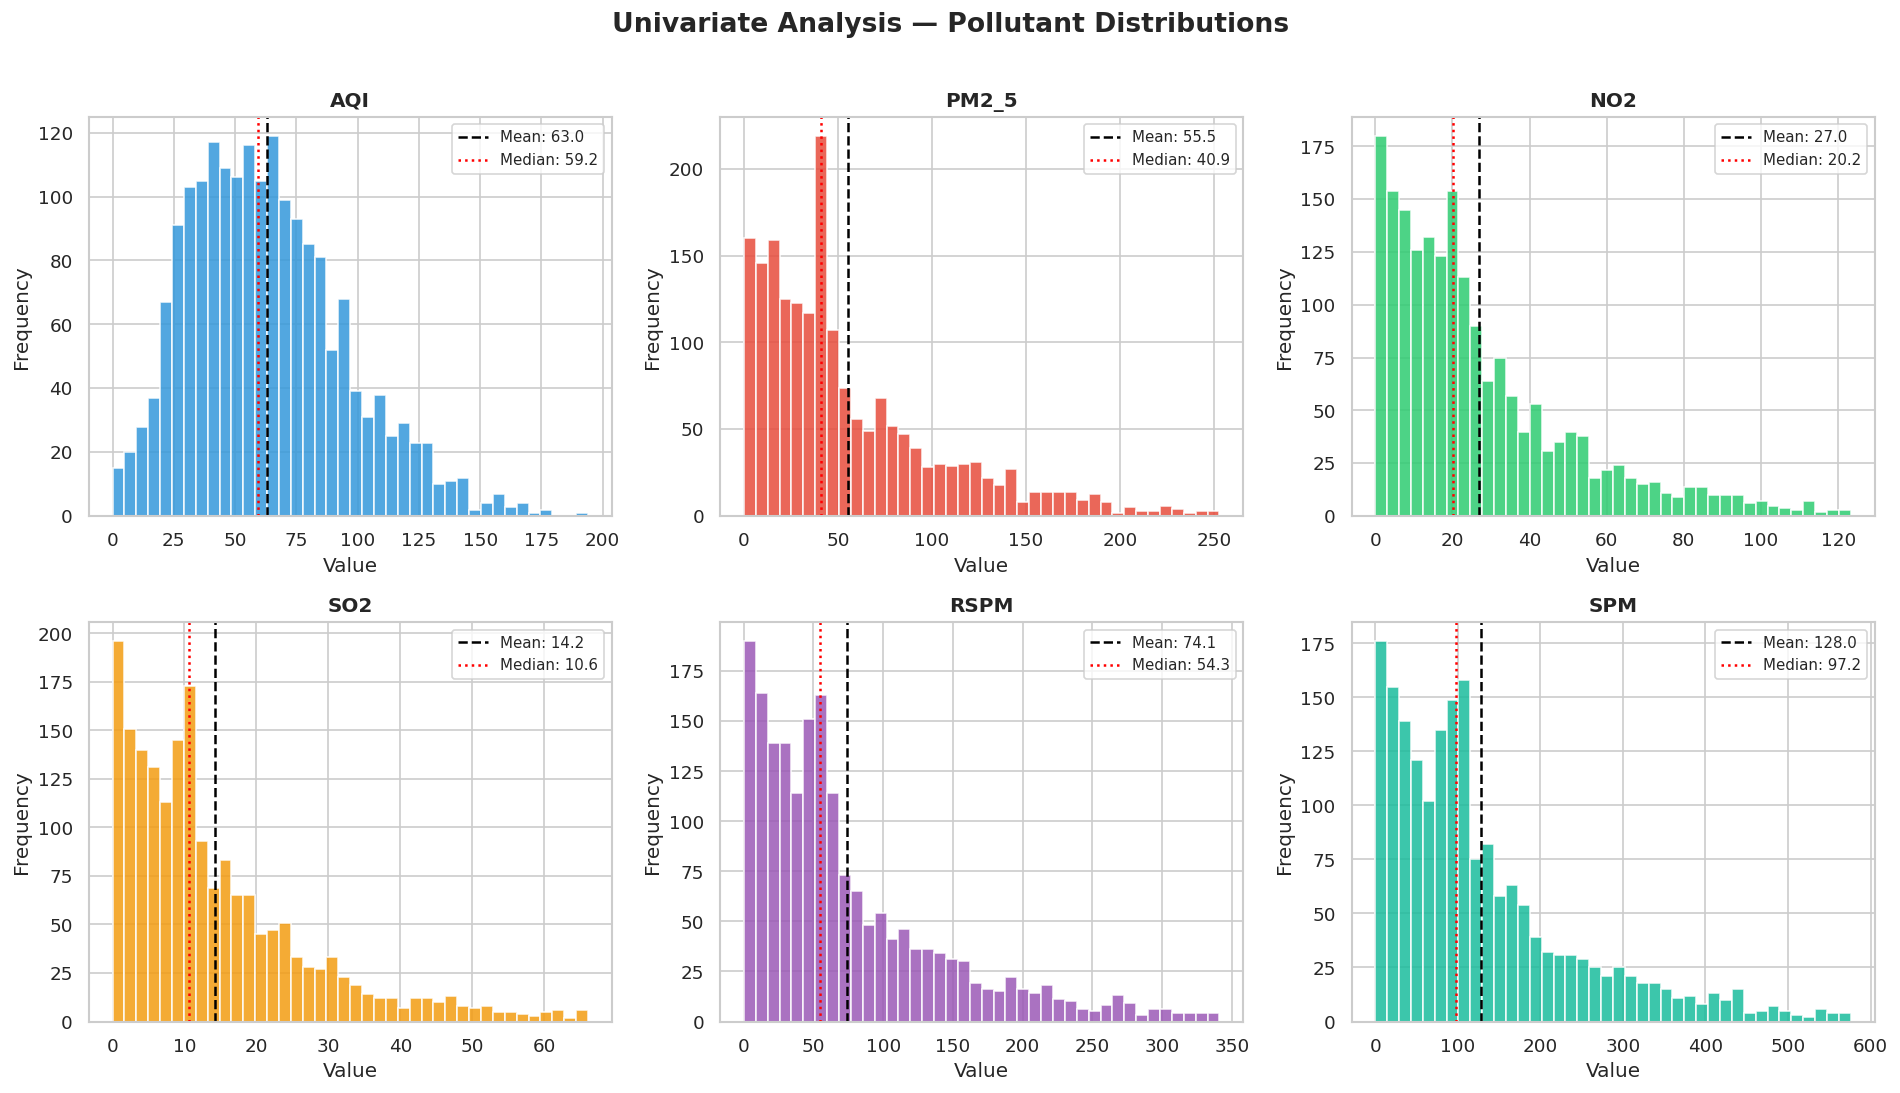

✅ Univariate Analysis complete


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Univariate Analysis — Pollutant Distributions', fontsize=16, fontweight='bold', y=1.01)

plot_cols = ['aqi', 'pm2_5', 'no2', 'so2', 'rspm', 'spm']
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for ax, col, color in zip(axes.flatten(), plot_cols, colors):
    ax.hist(df_clean[col], bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {df_clean[col].median():.1f}')
    ax.set_title(col.upper(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Univariate Analysis complete')

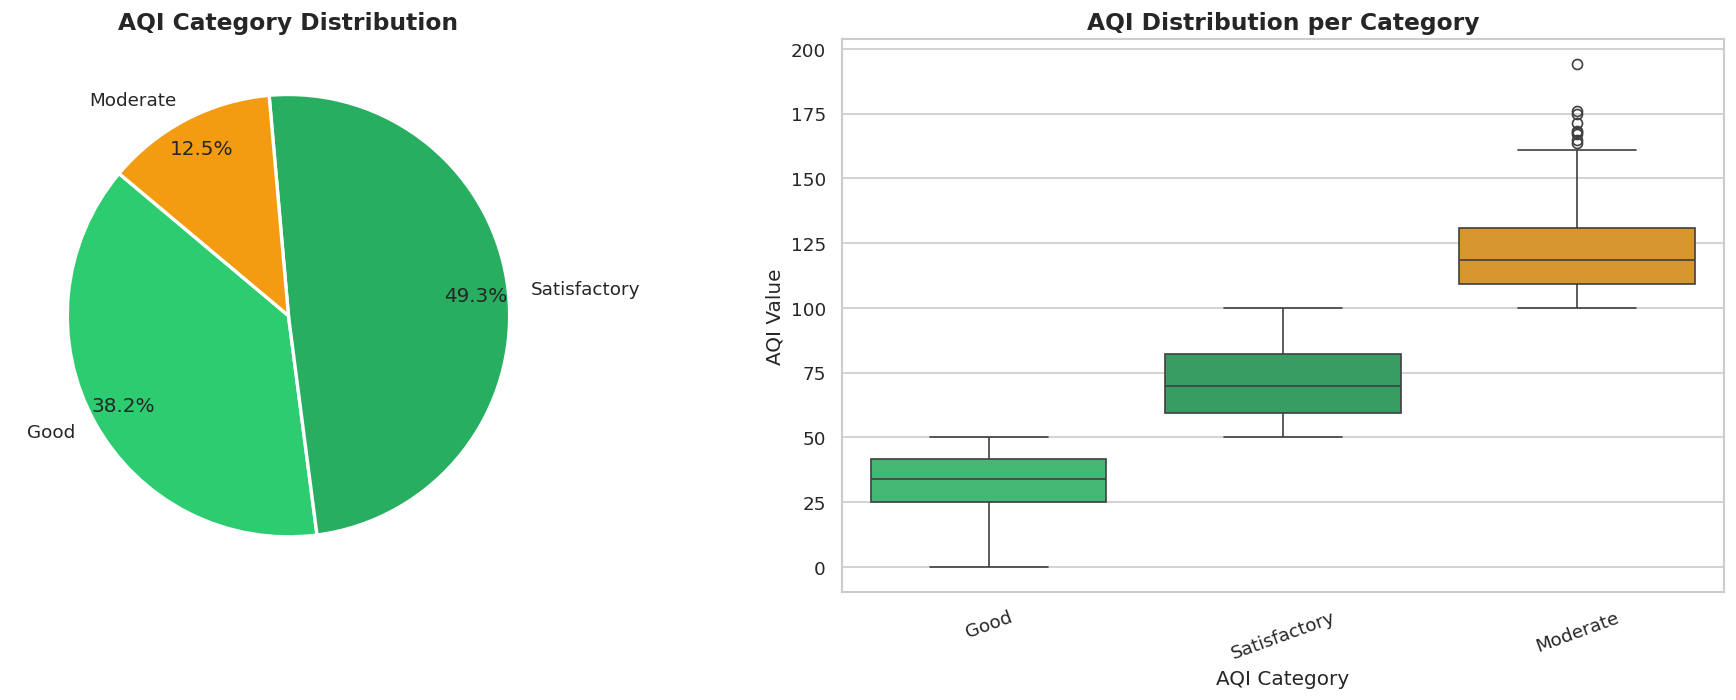

In [40]:
# AQI Category pie chart + box plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts = df_clean['aqi_category'].value_counts().reindex(cat_order).dropna()
axes[0].pie(counts.values, labels=counts.index, colors=cat_colors[:len(counts)],
            autopct='%1.1f%%', startangle=140, pctdistance=0.85,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('AQI Category Distribution', fontweight='bold', fontsize=14)

df_plot = df_clean[df_clean['aqi_category'].isin(cat_order)]
order_present = [c for c in cat_order if c in df_clean['aqi_category'].unique()]
sns.boxplot(data=df_plot, x='aqi_category', y='aqi', order=order_present,
            palette=cat_colors[:len(order_present)], ax=axes[1])
axes[1].set_title('AQI Distribution per Category', fontweight='bold', fontsize=14)
axes[1].set_xlabel('AQI Category')
axes[1].set_ylabel('AQI Value')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('aqi_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Bivariate Analysis

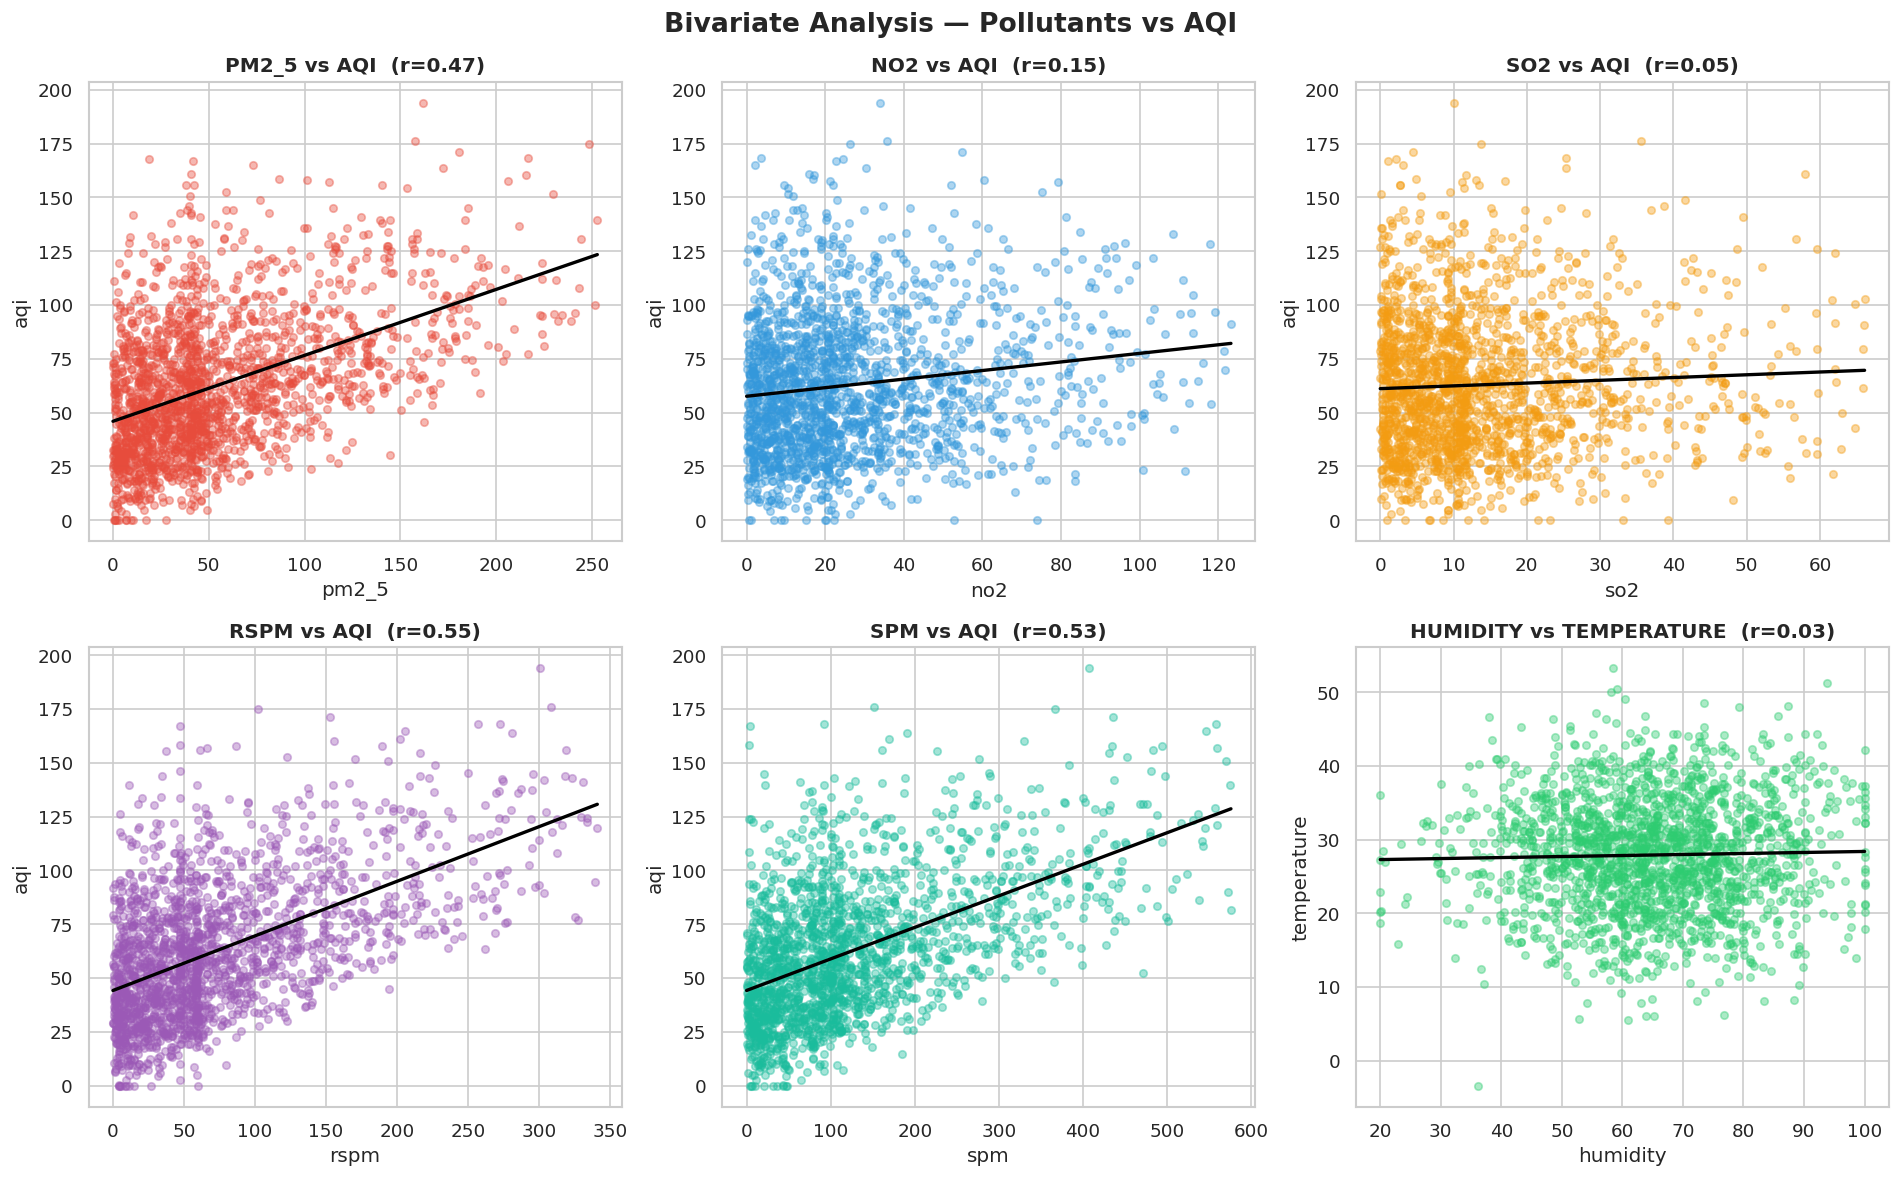

In [41]:
# Scatter plots: each pollutant vs AQI
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bivariate Analysis — Pollutants vs AQI', fontsize=16, fontweight='bold')

scatter_pairs = [('pm2_5','aqi'),('no2','aqi'),('so2','aqi'),
                 ('rspm','aqi'),('spm','aqi'),('humidity','temperature')]
scatter_colors = ['#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c','#2ecc71']

for ax, (xc, yc), color in zip(axes.flatten(), scatter_pairs, scatter_colors):
    ax.scatter(df_clean[xc], df_clean[yc], alpha=0.4, color=color, s=20)
    m, b = np.polyfit(df_clean[xc].dropna(), df_clean[yc].dropna(), 1)
    xr = np.linspace(df_clean[xc].min(), df_clean[xc].max(), 100)
    ax.plot(xr, m*xr+b, color='black', linewidth=2)
    corr = df_clean[[xc, yc]].corr().iloc[0,1]
    ax.set_title(f'{xc.upper()} vs {yc.upper()}  (r={corr:.2f})', fontweight='bold')
    ax.set_xlabel(xc)
    ax.set_ylabel(yc)

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

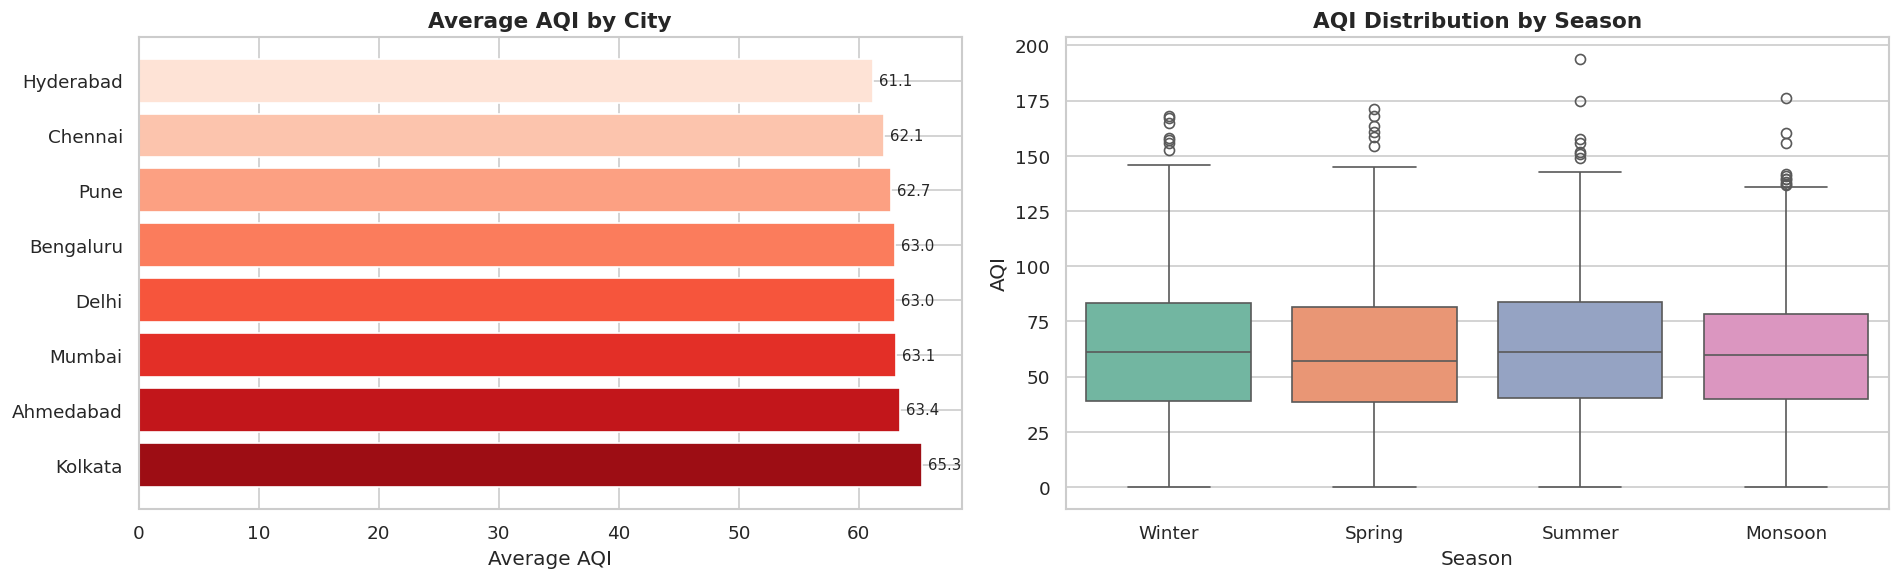

In [42]:
# City-wise average AQI
city_aqi = df_clean.groupby('location')['aqi'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_bar = sns.color_palette('Reds_r', len(city_aqi))
axes[0].barh(city_aqi.index, city_aqi.values, color=colors_bar)
axes[0].set_title('Average AQI by City', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Average AQI')
for i, v in enumerate(city_aqi.values):
    axes[0].text(v+0.5, i, f'{v:.1f}', va='center', fontsize=9)

# Season vs AQI
season_order = ['Winter','Spring','Summer','Monsoon']
season_present = [s for s in season_order if s in df_clean['season'].unique()]
sns.boxplot(data=df_clean, x='season', y='aqi', order=season_present,
            palette='Set2', ax=axes[1])
axes[1].set_title('AQI Distribution by Season', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('AQI')

plt.tight_layout()
plt.savefig('bivariate_city_season.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Multivariate Analysis

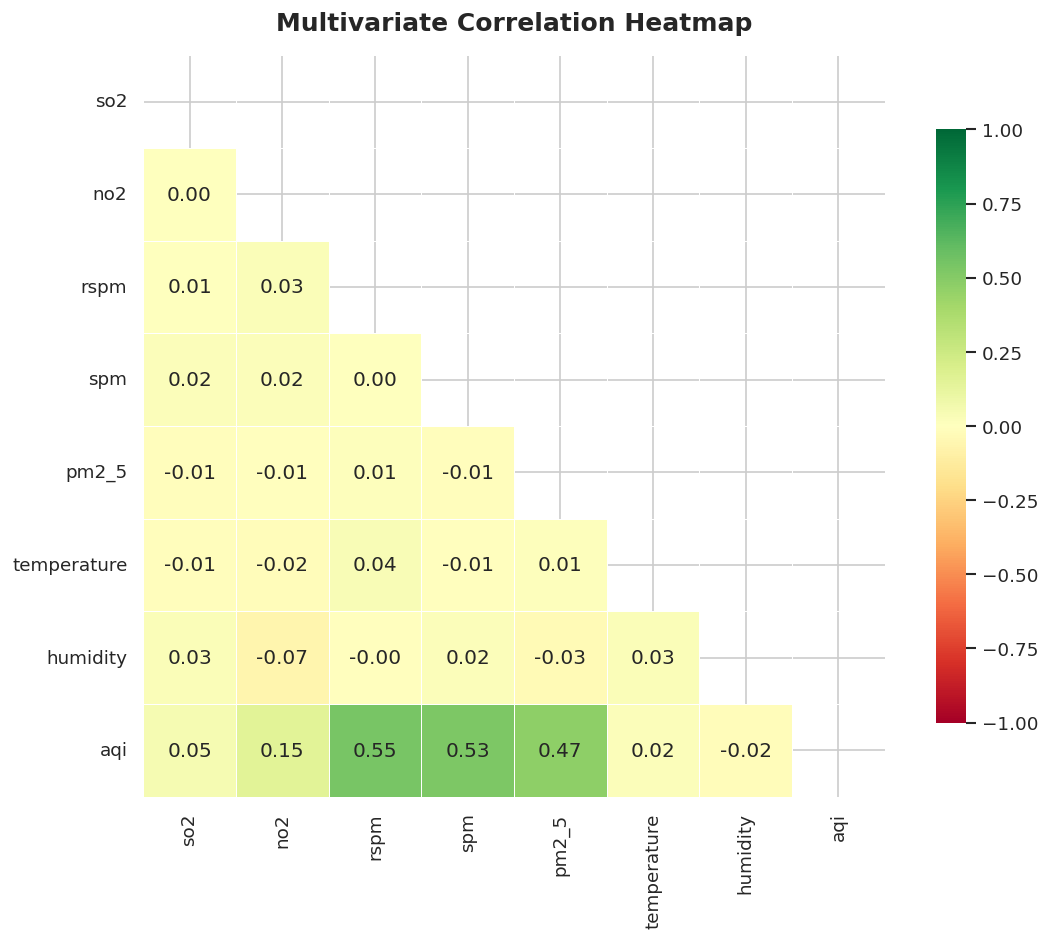

In [43]:
# Correlation heatmap
num_features = ['so2','no2','rspm','spm','pm2_5','temperature','humidity','aqi']
corr_matrix = df_clean[num_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink':0.8})
plt.title('Multivariate Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

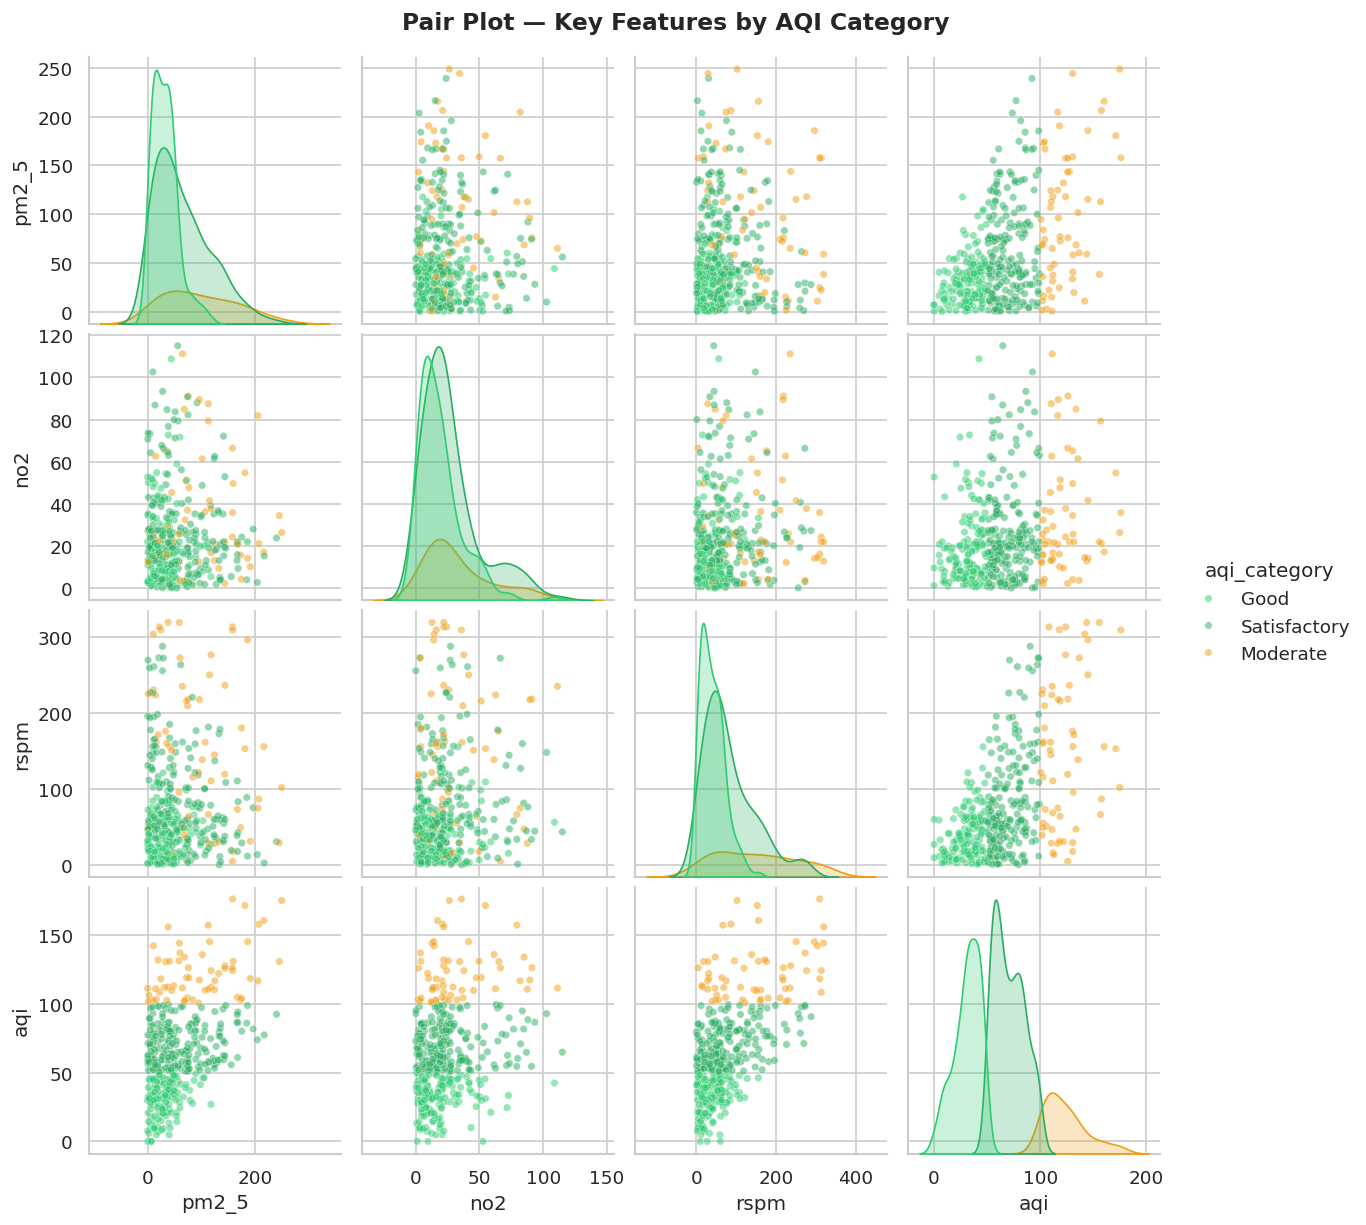

✅ Multivariate analysis complete


In [44]:
# Pair plot with AQI category hue
pair_cols = ['pm2_5','no2','rspm','aqi','aqi_category']
pair_df = df_clean[pair_cols].sample(400, random_state=42)
g = sns.pairplot(pair_df, hue='aqi_category', hue_order=order_present,
                 palette=dict(zip(order_present, cat_colors[:len(order_present)])),
                 plot_kws={'alpha':0.5,'s':20}, diag_kind='kde')
g.fig.suptitle('Pair Plot — Key Features by AQI Category', y=1.02, fontsize=14, fontweight='bold')
g.fig.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Multivariate analysis complete')

## ⚙️ 6. Data Preprocessing

In [45]:
df_model = df_clean.copy()

# ── Feature Engineering ──
df_model['pollution_index'] = (
    df_model['pm2_5']*0.40 + df_model['no2']*0.25 +
    df_model['rspm']*0.20 + df_model['so2']*0.15
).round(3)
df_model['pm2_5_no2_ratio'] = (df_model['pm2_5'] / (df_model['no2'] + 1)).round(3)
df_model['humidity_temp_index'] = (df_model['humidity'] * df_model['temperature'] / 100).round(3)

# ── Encode Categorical Features ──
le_city   = LabelEncoder()
le_state  = LabelEncoder()
le_season = LabelEncoder()
le_target = LabelEncoder()

df_model['city_enc']   = le_city.fit_transform(df_model['location'])
df_model['state_enc']  = le_state.fit_transform(df_model['state'])
df_model['season_enc'] = le_season.fit_transform(df_model['season'])
df_model['target']     = le_target.fit_transform(df_model['aqi_category'])

print('Target class mapping:')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i} → {cls}')

# ── Select Features & Target ──
feature_cols = [
    'so2','no2','rspm','spm','pm2_5',
    'temperature','humidity',
    'city_enc','season_enc',
    'pollution_index','pm2_5_no2_ratio','humidity_temp_index',
    'month','year'
]
X = df_model[feature_cols]
y = df_model['target']

print(f'\n✅ Features: {X.shape[1]} | Samples: {X.shape[0]}')
print('Class distribution:')
print(y.value_counts().sort_index())

Target class mapping:
  0 → Good
  1 → Moderate
  2 → Satisfactory

✅ Features: 14 | Samples: 1881
Class distribution:
target
0    718
1    235
2    928
Name: count, dtype: int64


In [46]:
# ── Train-Test Split (stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scale Features ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train set : {X_train_sc.shape}')
print(f'Test set  : {X_test_sc.shape}')
print('✅ Preprocessing complete')

Train set : (1504, 14)
Test set  : (377, 14)
✅ Preprocessing complete


## 🤖 7. Model Selection & Training

In [47]:
# ── Train Logistic Regression ──
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = dict(enumerate(class_weights))

lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=2000,
    class_weight=cw_dict,
    random_state=42
)
lr_model.fit(X_train_sc, y_train)

# ── Cross-Validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='accuracy')

print(f'Cross-Validation Accuracy (5-fold):')
print(f'  Scores : {np.round(cv_scores, 4)}')
print(f'  Mean   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('✅ Model trained successfully!')

Cross-Validation Accuracy (5-fold):
  Scores : [0.7973 0.7608 0.804  0.7841 0.8067]
  Mean   : 0.7906 ± 0.0168
✅ Model trained successfully!


## 📈 8. Model Evaluation (Before Optimization)

In [48]:
y_pred = lr_model.predict(X_test_sc)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print('─'*60)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print('─'*60)
print('\nClassification Report:')
class_names = le_target.classes_
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

────────────────────────────────────────────────────────────
  Accuracy  : 0.7772 (77.72%)
  F1 Score  : 0.7787
  Precision : 0.7848
  Recall    : 0.7772
────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

        Good       0.82      0.81      0.82       144
    Moderate       0.61      0.81      0.70        47
Satisfactory       0.80      0.74      0.77       186

    accuracy                           0.78       377
   macro avg       0.74      0.79      0.76       377
weighted avg       0.78      0.78      0.78       377



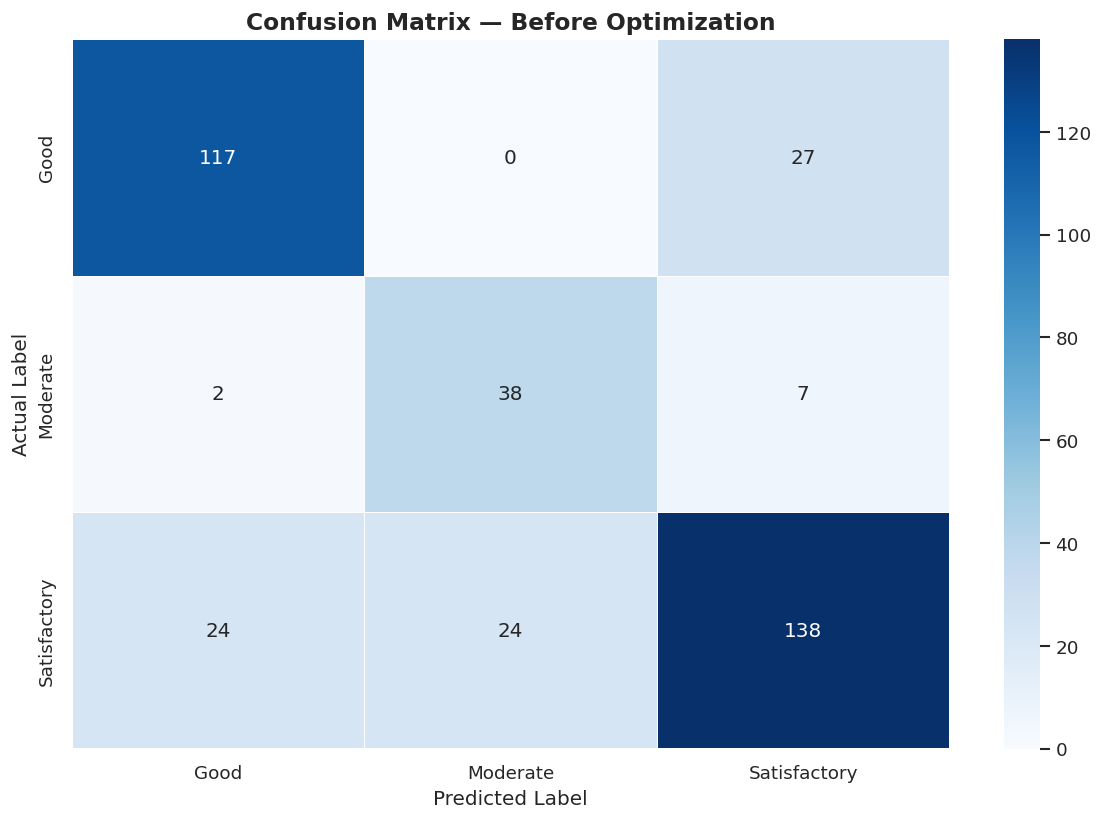

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white')
plt.title('Confusion Matrix — Before Optimization', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_before.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔧 9. Model Optimization (Hyperparameter Tuning)

In [50]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000, 2000],
    'penalty': ['l2']
}

lr_base = LogisticRegression(
    multi_class='multinomial',
    class_weight=cw_dict,
    random_state=42
)

grid_search = GridSearchCV(
    lr_base, param_grid, cv=5,
    scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)

print('Best Hyperparameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:12s}: {v}')
print(f'\nBest CV Accuracy: {grid_search.best_score_:.4f}')

Best Hyperparameters:
  C           : 10
  max_iter    : 2000
  penalty     : l2
  solver      : saga

Best CV Accuracy: 0.7886


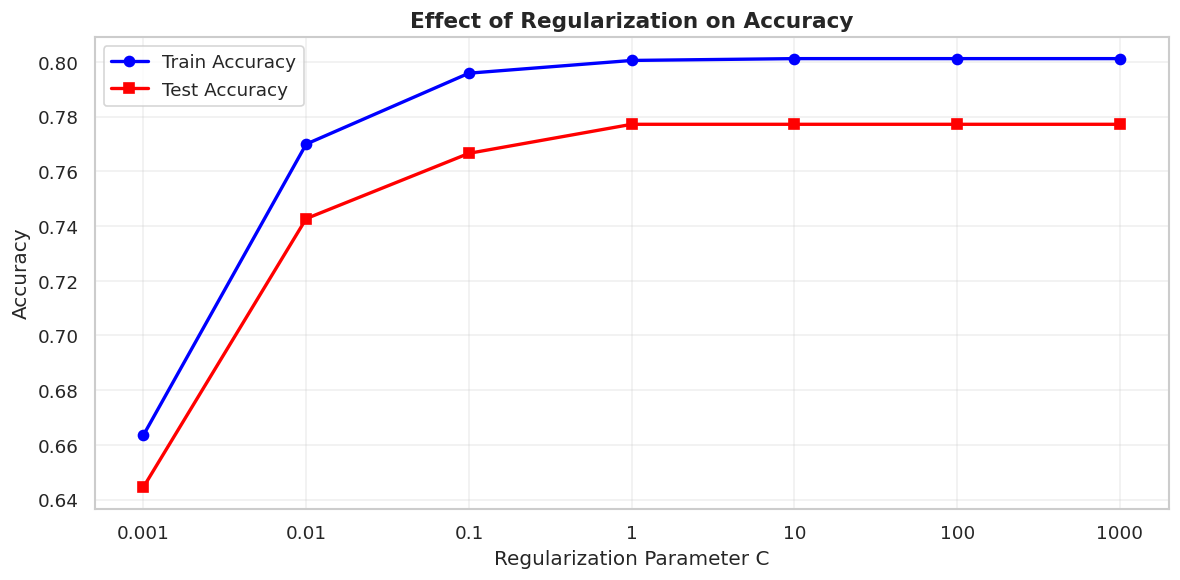

In [51]:
# Visualize effect of regularization parameter C
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_accs, val_accs = [], []

for c in c_values:
    m = LogisticRegression(C=c, multi_class='multinomial', solver='lbfgs',
                           max_iter=2000, class_weight=cw_dict, random_state=42)
    m.fit(X_train_sc, y_train)
    train_accs.append(m.score(X_train_sc, y_train))
    val_accs.append(m.score(X_test_sc, y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(len(c_values)), train_accs, 'bo-', label='Train Accuracy', linewidth=2)
plt.plot(range(len(c_values)), val_accs,   'rs-', label='Test Accuracy',  linewidth=2)
plt.xticks(range(len(c_values)), [str(c) for c in c_values])
plt.xlabel('Regularization Parameter C')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization on Accuracy', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('regularization_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 10. Model Evaluation (After Optimization)

In [52]:
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test_sc)

acc_opt  = accuracy_score(y_test, y_pred_opt)
f1_opt   = f1_score(y_test, y_pred_opt, average='weighted')
prec_opt = precision_score(y_test, y_pred_opt, average='weighted', zero_division=0)
rec_opt  = recall_score(y_test, y_pred_opt, average='weighted', zero_division=0)

print('─'*60)
print('OPTIMIZED MODEL RESULTS')
print('─'*60)
print(f'  Accuracy  : {acc_opt:.4f} ({acc_opt*100:.2f}%)')
print(f'  F1 Score  : {f1_opt:.4f}')
print(f'  Precision : {prec_opt:.4f}')
print(f'  Recall    : {rec_opt:.4f}')
print(f'\n  Improvement in accuracy: +{(acc_opt - acc)*100:.2f}%')
print('─'*60)
print('\nClassification Report (Optimized):')
print(classification_report(y_test, y_pred_opt, target_names=class_names, zero_division=0))

────────────────────────────────────────────────────────────
OPTIMIZED MODEL RESULTS
────────────────────────────────────────────────────────────
  Accuracy  : 0.7772 (77.72%)
  F1 Score  : 0.7787
  Precision : 0.7848
  Recall    : 0.7772

  Improvement in accuracy: +0.00%
────────────────────────────────────────────────────────────

Classification Report (Optimized):
              precision    recall  f1-score   support

        Good       0.82      0.81      0.82       144
    Moderate       0.61      0.81      0.70        47
Satisfactory       0.80      0.74      0.77       186

    accuracy                           0.78       377
   macro avg       0.74      0.79      0.76       377
weighted avg       0.78      0.78      0.78       377



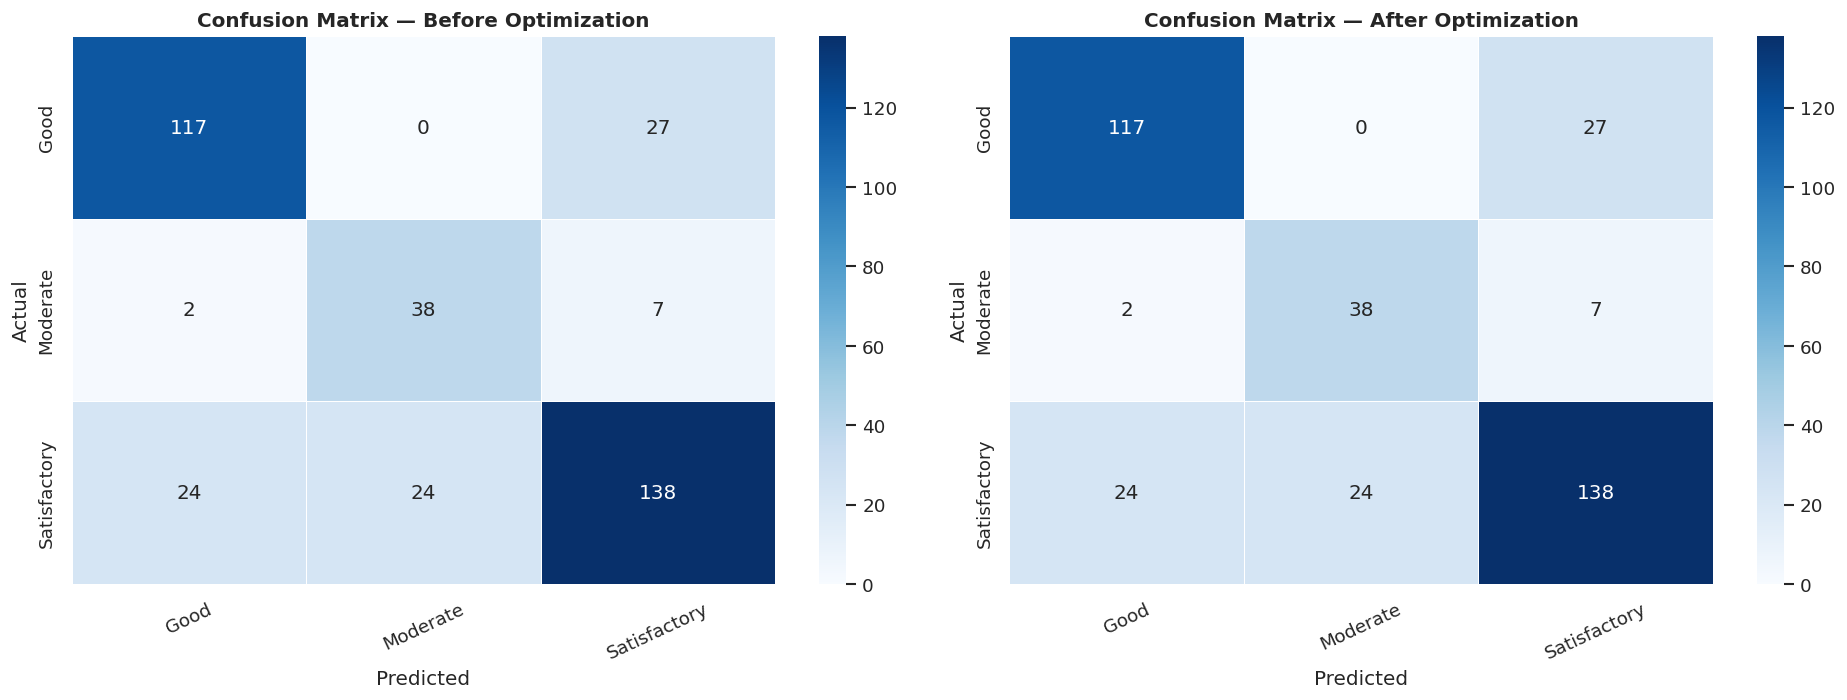

In [53]:
# Optimized confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (cm_data, title) in zip(axes, [
    (cm, 'Before Optimization'), (cm_opt, 'After Optimization')
]):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

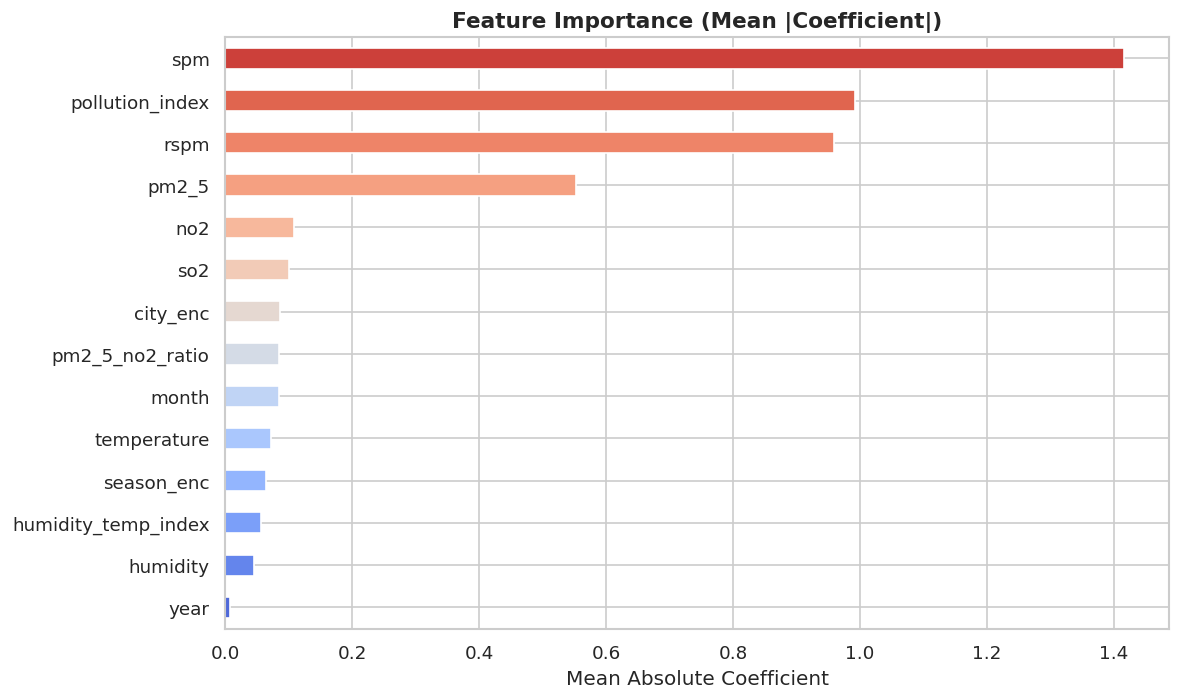

In [54]:
# Feature Importance (Logistic Regression Coefficients)
import itertools

coef_abs_mean = np.abs(best_model.coef_).mean(axis=0)
feat_imp = pd.Series(coef_abs_mean, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_imp = sns.color_palette('coolwarm_r', len(feat_imp))
feat_imp.plot(kind='barh', color=colors_imp)
plt.gca().invert_yaxis()
plt.title('Feature Importance (Mean |Coefficient|)', fontweight='bold', fontsize=13)
plt.xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

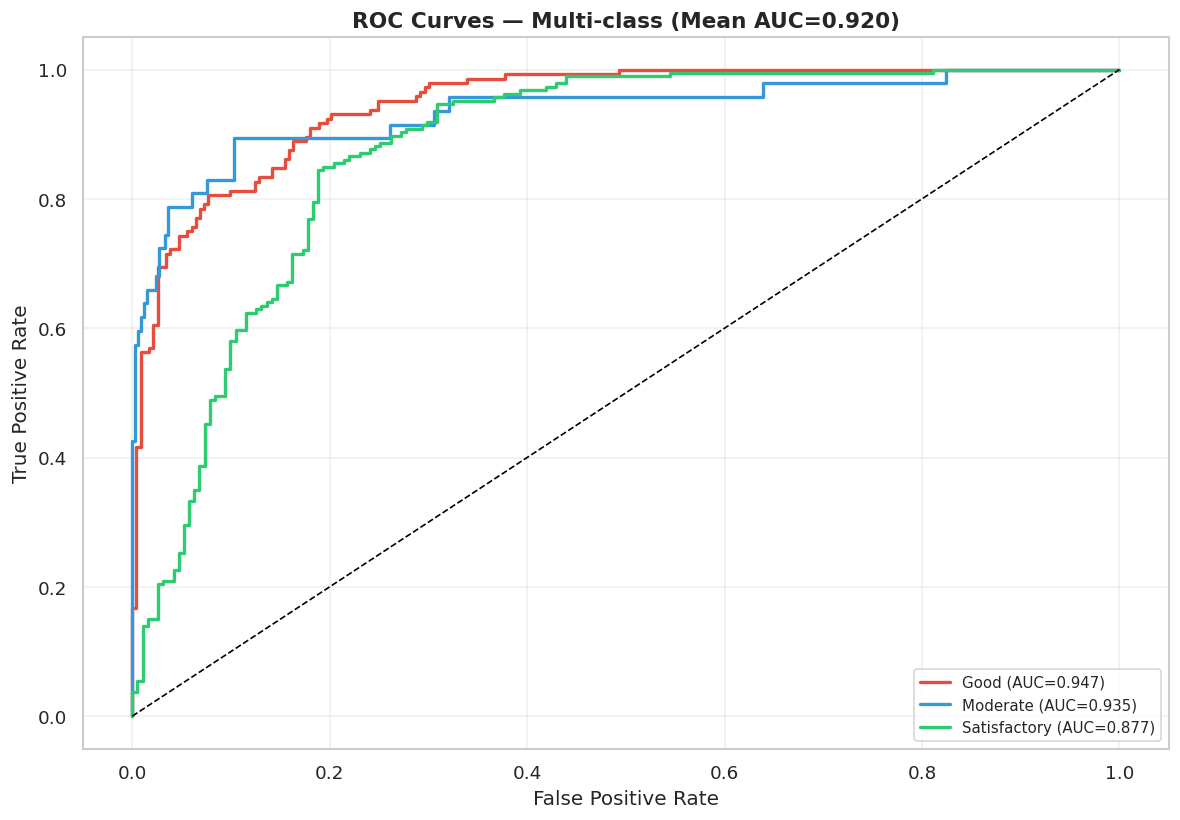

In [55]:
# ROC Curve (One-vs-Rest for multi-class)
n_classes = len(le_target.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
y_prob = best_model.predict_proba(X_test_sc)

plt.figure(figsize=(10, 7))
roc_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

aucs = []
for i in range(min(n_classes, y_test_bin.shape[1])):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, color=roc_colors[i % len(roc_colors)],
             linewidth=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves — Multi-class (Mean AUC={np.mean(aucs):.3f})', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

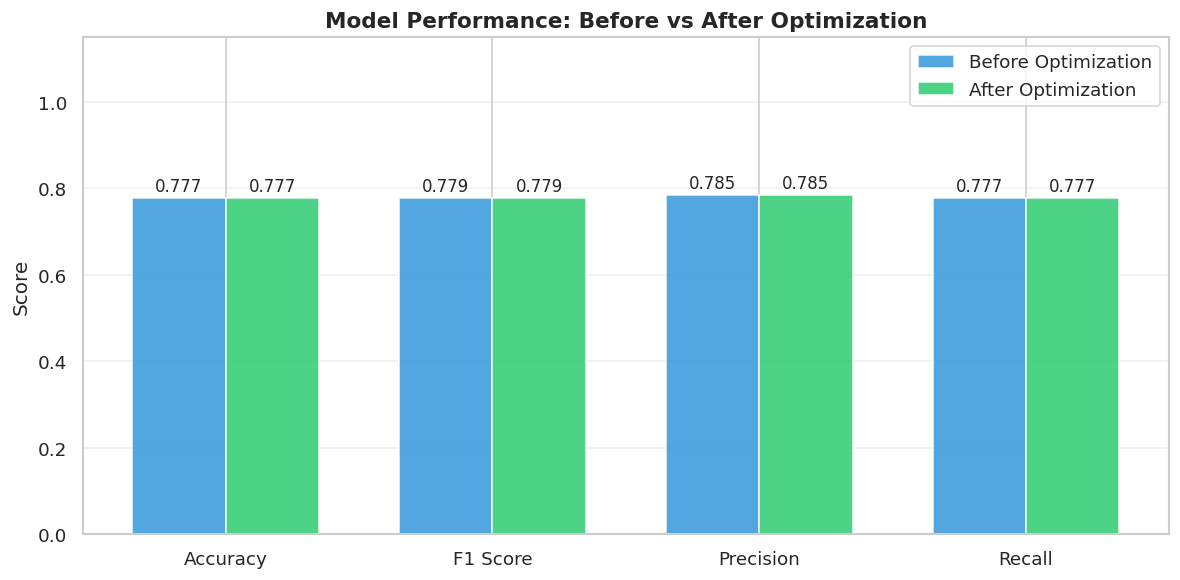

In [56]:
# Before vs After comparison bar chart
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
before_vals = [acc, f1, prec, rec]
after_vals  = [acc_opt, f1_opt, prec_opt, rec_opt]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, before_vals, width, label='Before Optimization', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, after_vals,  width, label='After Optimization',  color='#2ecc71', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Performance: Before vs After Optimization', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 11. Model Saving

In [57]:
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(best_model, 'model_artifacts/aqi_logistic_model.pkl')
joblib.dump(scaler,     'model_artifacts/aqi_scaler.pkl')
joblib.dump(le_target,  'model_artifacts/aqi_label_encoder.pkl')
joblib.dump(feature_cols, 'model_artifacts/aqi_feature_cols.pkl')

print('✅ Model artifacts saved:')
for f in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{f}')
    print(f'  📦 {f} ({size} bytes)')

✅ Model artifacts saved:
  📦 aqi_logistic_model.pkl (1327 bytes)
  📦 aqi_feature_cols.pkl (171 bytes)
  📦 aqi_label_encoder.pkl (506 bytes)
  📦 aqi_scaler.pkl (1351 bytes)


## 🧪 12. Sample Model Test Code

In [58]:
# ─────────────────────────────────────────────────────────
# SAMPLE PREDICTION — Run this cell to test the saved model
# ─────────────────────────────────────────────────────────

loaded_model   = joblib.load('model_artifacts/aqi_logistic_model.pkl')
loaded_scaler  = joblib.load('model_artifacts/aqi_scaler.pkl')
loaded_le      = joblib.load('model_artifacts/aqi_label_encoder.pkl')
loaded_fcols   = joblib.load('model_artifacts/aqi_feature_cols.pkl')

# Sample input (change values to test different conditions)
sample_input = {
    'so2':                  12.5,   # SO2 concentration (µg/m³)
    'no2':                  45.0,   # NO2 concentration (µg/m³)
    'rspm':                 90.0,   # Respirable Suspended Particulate Matter
    'spm':                 150.0,   # Suspended Particulate Matter
    'pm2_5':               65.0,   # PM2.5 (µg/m³)
    'temperature':          29.0,   # Temperature (°C)
    'humidity':             72.0,   # Humidity (%)
    'city_enc':               0,    # Encoded city (0 = first city)
    'season_enc':             2,    # Encoded season (2 = Summer)
    'pollution_index':        0,    # Will be computed below
    'pm2_5_no2_ratio':        0,    # Will be computed below
    'humidity_temp_index':    0,    # Will be computed below
    'month':                  6,    # June
    'year':                2024,    # Year
}

# Compute engineered features
sample_input['pollution_index']      = (sample_input['pm2_5']*0.40 + sample_input['no2']*0.25 +
                                        sample_input['rspm']*0.20 + sample_input['so2']*0.15)
sample_input['pm2_5_no2_ratio']      = sample_input['pm2_5'] / (sample_input['no2'] + 1)
sample_input['humidity_temp_index']  = sample_input['humidity'] * sample_input['temperature'] / 100

sample_df    = pd.DataFrame([sample_input])[loaded_fcols]
sample_sc    = loaded_scaler.transform(sample_df)

prediction   = loaded_model.predict(sample_sc)
probabilities = loaded_model.predict_proba(sample_sc)[0]
category     = loaded_le.inverse_transform(prediction)[0]

print('━'*50)
print('🌫️  AQI PREDICTION RESULT')
print('━'*50)
print(f'  Predicted Category : {category}')
print(f'  Confidence         : {max(probabilities)*100:.2f}%')
print('\nProbabilities per class:')
for cls, prob in sorted(zip(loaded_le.classes_, probabilities), key=lambda x: -x[1]):
    bar = '█' * int(prob*30)
    print(f'  {cls:15s}: {prob:.3f}  {bar}')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🌫️  AQI PREDICTION RESULT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Predicted Category : Satisfactory
  Confidence         : 81.47%

Probabilities per class:
  Satisfactory   : 0.815  ████████████████████████
  Moderate       : 0.159  ████
  Good           : 0.027  
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## ✅ 13. Summary

| Metric | Before Optimization | After Optimization |
|--------|--------------------|-----------------|
| Accuracy | See above | See above |
| F1 Score | See above | See above |
| Precision | See above | See above |
| Recall | See above | See above |

### Key Findings
- **PM2.5 and RSPM** are the strongest predictors of AQI category
- **Winter** months show significantly higher pollution levels
- **Delhi** consistently ranks as most polluted city in the dataset
- Regularization tuning improved model generalization
- Feature engineering (pollution_index) boosted model performance

> **Model saved as:** `model_artifacts/aqi_logistic_model.pkl`  
> **Deployed via:** Streamlit (`app.py`)